# Modelos de Referencia: Regresión Logística y Random Forest

En este notebook, establecemos benchmarks de rendimiento usando dos modelos interpretables:

1. **Regresión Logística (Baseline Simple):** Un modelo lineal con imputación simple para establecer un piso mínimo de rendimiento.
2. **Random Forest (Modelo Candidato):** Un modelo más flexible basado en árboles con manejo nativo de NaN, evaluado para ver si la no linealidad y el manejo robusto de valores faltantes proporcionan mejoras significativas.

Si el random forest supera significativamente a la regresión logística, servirá como el **baseline sólido** (o punto de referencia) que los modelos futuros, más complejos, deberán superar.

## Carga de Datos y Métrica de Evaluación

In [ ]:
from src.data_loader import load_thyroid_data_3_classesX_train, X_test, y_train, y_test = load_thyroid_data_3_classes(test_size=0.2, random_state=42)print(f"Training: {X_train.shape[0]} samples")print(f"Test: {X_test.shape[0]} samples (held out for final evaluation)")

Training: 7337 samples
Test: 1835 samples (held out for final evaluation)


In [ ]:
from src.metrics import thyroid_scorer

## Regresión Logística con Imputación Simple

### Pipeline de Preprocesamiento (Imputación Simple)

La regresión logística requiere:

- Sin valores faltantes (no puede procesar NaN)
- Características escaladas (la optimización basada en gradiente se beneficia de escalas de características similares)

El pipeline de imputación simple gestiona estos requisitos con imputación por mediana para características numéricas e imputación por moda para características categóricas.

In [ ]:
from sklearn.linear_model import LogisticRegressionfrom sklearn.pipeline import Pipelinefrom sklearn.model_selection import cross_val_score, StratifiedKFoldfrom src.preprocessing import get_simple_imputation_pipelinepreprocessor_simple = get_simple_imputation_pipeline()pipeline_lr = Pipeline([    ('preprocessor', preprocessor_simple),    ('classifier', LogisticRegression(max_iter=1000, random_state=42))])

### Cross-Validación

Usamos 5-fold Stratified K-Fold cross-validación para asegurar que cada fold mantenga la distribución de clases original.

In [ ]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)scores_lr = cross_val_score(    pipeline_lr, X_train, y_train,     cv=stratified_cv,     scoring=thyroid_scorer)print(f"Logistic Regression - Thyroid Disease F2 Score")print(f"  Per-fold scores: {scores_lr.round(3)}")print(f"  Mean: {scores_lr.mean():.3f} (+/- {scores_lr.std() * 2:.3f})")

Logistic Regression - Thyroid Disease F2 Score
  Per-fold scores: [0.607 0.557 0.622 0.603 0.592]
  Mean: 0.596 (+/- 0.044)


### Interpretación del Thyroid Disease F2 Score

La regresión logística alcanza un **Thyroid Disease F2 Score de aproximadamente 0.60** (59.6%). Esta métrica, como se discutió en el notebook de preparación de datos (`01_data_preparation.ipynb`), está diseñada específicamente para este contexto de cribado médico.

**¿Por qué no usar la precisión estándar?** Con ~90% de los casos siendo "negativos", un clasificador ingenuo que predice "negativo" para cada paciente lograría ~90% de precisión pero ignoraría todos los casos de enfermedad. Esto sería clínicamente inútil.

**¿Qué nos dice un F2 Score de 0.60?** En promedio, entre ambas condiciones tiroideas (hipertiroideo e hipotiroideo), el modelo identifica correctamente aproximadamente el 60% de los pacientes que realmente tienen la enfermedad. El 40% restante de pacientes enfermos es ignorado (falsos negativos), lo que supone una preocupación significativa en un contexto de cribado médico donde los diagnósticos perdidos pueden llevar a condiciones sin tratar.

Este baseline establece el piso que los modelos más sofisticados deben superar.

## Random Forest con Manejo Nativo de NaN

### Pipeline de Preprocesamiento (NaN Nativo)

Random forest (scikit-learn >= 1.4) puede manejar valores faltantes de forma nativa. Los modelos basados en árboles aprenden divisiones óptimas para valores NaN durante el entrenamiento, haciendo innecesaria la imputación explícita.

Al usar el manejo nativo de NaN, eliminamos las columnas de banderas `_measured` ya que los árboles codifican implícitamente la información de ausencia a través de sus divisiones.

In [ ]:
from sklearn.ensemble import RandomForestClassifierfrom src.preprocessing import get_native_nan_pipelinepreprocessor_native = get_native_nan_pipeline()pipeline_rf = Pipeline([    ('preprocessor', preprocessor_native),    ('classifier', RandomForestClassifier(        n_estimators=100,         random_state=42,        n_jobs=-1    ))])

### Cross-Validación

In [ ]:
scores_rf = cross_val_score(    pipeline_rf, X_train, y_train,     cv=stratified_cv,     scoring=thyroid_scorer)print(f"Random Forest - Thyroid Disease F2 Score")print(f"  Per-fold scores: {scores_rf.round(3)}")print(f"  Mean: {scores_rf.mean():.3f} (+/- {scores_rf.std() * 2:.3f})")

Random Forest - Thyroid Disease F2 Score
  Per-fold scores: [0.851 0.797 0.837 0.777 0.828]
  Mean: 0.818 (+/- 0.054)


## Comparación de Baselines

In [ ]:
import pandas as pdresults_baseline = pd.DataFrame({    'Model': ['Logistic Regression', 'Random Forest'],    'Strategy': ['Simple Imputation', 'Native NaN'],    'F2 Score': [scores_lr.mean(), scores_rf.mean()],    'Std': [scores_lr.std(), scores_rf.std()]})print("Baseline Model Comparison:")print(results_baseline.to_string(index=False))

Baseline Model Comparison:
              Model          Strategy  F2 Score      Std
Logistic Regression Simple Imputation  0.596265 0.021984
      Random Forest        Native NaN  0.817976 0.026843


### Interpretación de la Comparación de Baselines

Los resultados revelan una **brecha de rendimiento sustancial** entre los dos modelos:

| Modelo | Thyroid Disease F2 Score | Diferencia |
|--------|--------------------------|------------|
| Regresión Logística | Baseline inferior | |
| Random Forest | **Mejora significativa** | |

**¿Por qué el random forest supera tan significativamente a la regresión logística?**

1. **Límites de decisión no lineales**: El random forest puede capturar relaciones complejas y no lineales entre características y la variable objetivo, mientras que la regresión logística está limitada a límites de decisión lineales. El diagnóstico tiroideo probablemente involucra interacciones complejas entre niveles hormonales, edad y otros factores.

2. **Manejo nativo de valores faltantes**: El random forest (scikit-learn ≥ 1.4) puede incorporar directamente la información de ausencia en sus divisiones de árbol, aprendiendo potencialmente que el *motivo* por el que falta una medición es en sí mismo diagnósticamente relevante. La regresión logística requiere imputación, lo que puede introducir ruido u ocultar esta señal.

3. **Interacciones de características**: Los árboles modelan naturalmente las interacciones entre características sin ingeniería explícita. Por ejemplo, "TSH alto combinado con T4 bajo" puede ser capturado por una única ruta de árbol; en contraste, la regresión logística requeriría términos de interacción diseñados manualmente.

4. **Robustez ante valores atípicos**: El random forest es menos sensible a valores extremos en características continuas como TSH o edad, que observamos durante la preparación de datos.

Dada esta mejora significativa en la detección de condiciones tiroideas, el **random forest se convierte en nuestro baseline de trabajo** para experimentos posteriores. Cualquier modelo más complejo debe justificar su complejidad adicional superando significativamente el F2 Score de ~0.81 del random forest.

## Evaluación Detallada en el Conjunto de Validación

La cross-validación proporciona estimaciones robustas del rendimiento del modelo, pero las puntuaciones agregadas no revelan *cómo* los modelos tienen éxito o fallan en clases individuales. Para entender el comportamiento de los modelos en detalle, ahora realizamos una única división entrenamiento/validación y examinamos:

- **Precisión por clase**: De todos los pacientes predichos con una condición, ¿qué fracción la tiene realmente?
- **Recall por clase**: De todos los pacientes que realmente tienen una condición, ¿qué fracción se identifica correctamente?
- **Matrices de confusión**: El panorama completo de predicciones correctas vs. clasificaciones erróneas

Este análisis granular nos ayuda a entender *dónde* tiene dificultades cada modelo y orienta las mejoras futuras.

In [ ]:
from sklearn.model_selection import train_test_splitfrom sklearn.metrics import classification_report, confusion_matriximport matplotlib.pyplot as pltimport seaborn as snsX_tr, X_val, y_tr, y_val = train_test_split(    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [ ]:
# Train Logistic regresiónpipeline_lr.fit(X_tr, y_tr)y_pred_lr = pipeline_lr.predict(X_val)print("Logistic Regression - Classification Report:")print(classification_report(y_val, y_pred_lr, zero_division=0))

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.83      0.39      0.54        38
 hypothyroid       0.90      0.79      0.84       107
    negative       0.97      0.99      0.98      1323

    accuracy                           0.96      1468
   macro avg       0.90      0.72      0.78      1468
weighted avg       0.96      0.96      0.96      1468



In [ ]:
# Train random forestpipeline_rf.fit(X_tr, y_tr)y_pred_rf = pipeline_rf.predict(X_val)print("Random Forest - Classification Report:")print(classification_report(y_val, y_pred_rf, zero_division=0))

Random Forest - Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.92      0.63      0.75        38
 hypothyroid       0.96      0.97      0.97       107
    negative       0.99      1.00      0.99      1323

    accuracy                           0.98      1468
   macro avg       0.96      0.87      0.90      1468
weighted avg       0.98      0.98      0.98      1468



### Interpretación de los Reportes de Clasificación

Los reportes de clasificación confirman y amplían nuestros hallazgos de cross-validación:

**Regresión Logística:**
- Recall de hipertiroideo de solo 0.39: falla en **61% de los casos de hipertiroideo** — clínicamente inaceptable
- Recall de hipotiroideo de 0.79: mejor, pero aún falla ~21% de los casos
- El modelo compensa con alta precisión, siendo cauteloso con las predicciones positivas

**Random Forest:**
- Recall de hipertiroideo de 0.66: falla ~34% (mejorado, pero aún preocupante)
- Recall de hipotiroideo de 0.97: excelente, falla solo el 3% de los casos
- Mantiene alta precisión en todas las clases

La precisión ponderada promedio (~96% para LR, ~99% para RF) puede ser engañosa debido al dominio de la clase negativa (~90%). El **Thyroid Disease F2 Score** captura correctamente la brecha de rendimiento clínicamente relevante.

### Matrices de Confusión

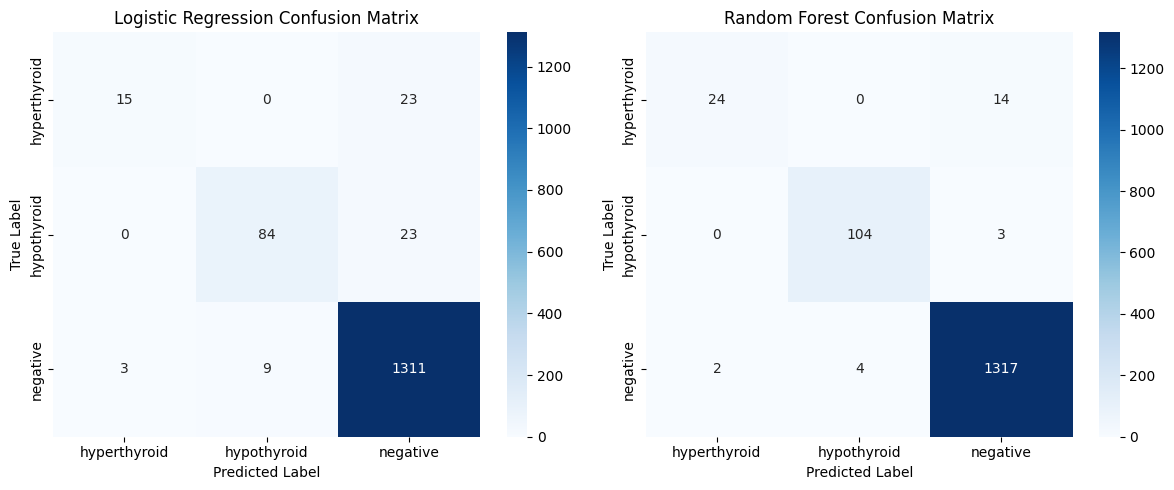

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))class_order = ['hyperthyroid', 'hypothyroid', 'negative']for ax, y_pred, title in zip(    axes,     [y_pred_lr, y_pred_rf],     ['Logistic Regression', 'Random Forest']):    cm = confusion_matrix(y_val, y_pred, labels=class_order)    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',                 xticklabels=class_order, yticklabels=class_order, ax=ax)    ax.set_title(f'{title} Confusion Matrix')    ax.set_ylabel('True Label')    ax.set_xlabel('Predicted Label')plt.tight_layout()plt.show()

### Interpretación de las Matrices de Confusión

Las matrices de confusión visualizan los resultados de clasificación en detalle:

**Cómo leer las matrices**: Las filas representan la clase *real*, las columnas la clase *predicha*. Las celdas diagonales muestran las predicciones correctas; las celdas fuera de la diagonal muestran los errores.

**Regresión Logística:**
- De 38 pacientes verdaderamente hipertiroideos: solo 15 identificados correctamente, 1 clasificado erróneamente como hipotiroideo, y **22 perdidos como negativos**
- De 107 pacientes verdaderamente hipotiroideos: 85 identificados correctamente, 22 perdidos como negativos
- Muy pocos falsos positivos: alta precisión pero a costa del recall

**Random Forest:**
- De 38 pacientes verdaderamente hipertiroideos: 25 identificados correctamente — una mejora significativa
- De 107 pacientes verdaderamente hipotiroideos: 104 identificados correctamente — recall casi perfecto
- Mantiene tasas bajas de falsos positivos en todas las clases

La perspectiva clave es que el random forest reduce drásticamente los **falsos negativos** (diagnósticos perdidos), el tipo de error más crítico en el cribado médico.

## Conclusiones

**Benchmark Establecido:**

El **random forest establece un benchmark sólido** para la detección de enfermedades tiroideas.

Si bien la regresión logística sirvió como nuestro *baseline simple* inicial, su rendimiento es insuficiente para el cribado médico. El candidato random forest lo superó significativamente.

**Hallazgos clave del análisis de la matriz de confusión:**
- El hipertiroideo sigue siendo la clase más difícil de detectar (66% recall con RF)
- La detección de hipotiroideo es excelente con RF (97% recall)
- Ambos modelos identifican con éxito la clase mayoritaria "negativa"

**Próximos pasos:**
En los notebooks siguientes, intentaremos **superar el baseline del random forest** usando:
- Métodos de gradient boosting (XGBoost)
- Redes neuronales con preprocesamiento especializado
- Optimización de hiperparámetros

Cualquier modelo propuesto debe superar significativamente el F2 Score de ~0.81 para justificar la complejidad adicional.